In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import h5py
import scipy.sparse as sp
import yaml
import time
import gget
import scipy
from scipy.stats import zscore
from tqdm import tqdm
from statsmodels.stats.multitest import multipletests
from itertools import combinations
from sklearn.metrics import confusion_matrix

import anndata as an
import scanpy as sc
import scanpy.external as sce
import rapids_singlecell as rsc

sc.settings.verbosity = 3

13:00:29 - INFO - Old pandas version detected. Patching DataFrame.map to DataFrame.applymap


# Load raw data

In [2]:
%%time
fpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/cc_fibroblast_full/anndata/cc_fibroblast.h5ad"
adata = sc.read_h5ad(fpath)
adata.obs.rename(columns={'phase' : 'barcoded_phase'}, inplace=True)
                                               
adata

CPU times: user 92.7 ms, sys: 274 ms, total: 367 ms
Wall time: 900 ms


AnnData object with n_obs × n_vars = 8963 × 23635
    obs: 'batch', 'barcoded_phase', 'nnz'
    var: 'gene_ids', 'feature_types', 'feature_id'

# Preprocessing

In [3]:
adata.raw = adata.copy()

sc.pp.filter_cells(adata, min_counts=500)
sc.pp.filter_genes(adata, min_counts=10)

# mitochondrial genes, "MT-" for human, "Mt-" for mouse
adata.var["mt"] = adata.var_names.str.startswith("MT-")
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")

sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt", "ribo", "hb"], 
    inplace=True, log1p=True
)

min_n_genes = 1000
adata = adata[adata.obs['n_genes_by_counts'] > min_n_genes, :].copy()

sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

adata

filtered out 283 cells that have less than 500 counts
filtered out 3438 genes that are detected in less than 10 counts
normalizing counts per cell
    finished (0:00:00)


AnnData object with n_obs × n_vars = 7540 × 20197
    obs: 'batch', 'barcoded_phase', 'nnz', 'n_counts', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb'
    var: 'gene_ids', 'feature_types', 'feature_id', 'n_counts', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'log1p'

# collect all cell cycle genes in a nice data frame

In [4]:
# Initialize list of all gene sources
sources = []

# --- Regev Gene Lists ---
regev_genes = [x.strip() for x in open('../../resources/regev_lab_cell_cycle_genes.txt')]
regev_s_genes = regev_genes[:43]
regev_g2m_genes = regev_genes[43:]

print(f"[Regev] Total: {len(regev_genes)} | S: {len(regev_s_genes)} | G2/M: {len(regev_g2m_genes)}")

sources.append(pd.DataFrame({
    'gene_name': regev_s_genes + regev_g2m_genes,
    'S_phase': [True]*len(regev_s_genes) + [False]*len(regev_g2m_genes),
    'G2M_phase': [False]*len(regev_s_genes) + [True]*len(regev_g2m_genes),
    'source': 'Regev'
}))

# --- Seurat Gene Lists ---
df_seurat = pd.read_csv("../../resources/seurat_genes.csv").set_index('gene_name')
seurat_s_genes = df_seurat[df_seurat['S']].index.to_list()
seurat_g2m_genes = df_seurat[df_seurat['G2M']].index.to_list()

print(f"[Seurat] S: {len(seurat_s_genes)} | G2/M: {len(seurat_g2m_genes)}")

sources.append(pd.DataFrame({
    'gene_name': seurat_s_genes + seurat_g2m_genes,
    'S_phase': [True]*len(seurat_s_genes) + [False]*len(seurat_g2m_genes),
    'G2M_phase': [False]*len(seurat_s_genes) + [True]*len(seurat_g2m_genes),
    'source': 'Seurat'
}))

# Combine all sources
combined_df = pd.concat(sources, ignore_index=True)

# Create a MultiIndex dataframe with gene as index and source as column level
pivot_df = combined_df.pivot_table(
    index='gene_name',
    columns='source',
    values=['S_phase', 'G2M_phase'],
    aggfunc='any',  # handle potential duplicates by combining with logical OR
    fill_value=False  # assume missing entries are False
)

# Flatten multi-level columns
pivot_df.columns = [f"{phase}_{source}" for phase, source in pivot_df.columns]
pivot_df = pivot_df.reset_index()

# Optional: sort by gene name
pivot_df = pivot_df.sort_values("gene_name").reset_index(drop=True)

# Final shape info
print(f"Final gene count: {pivot_df.shape[0]}")

# filter out genes not in our data
pivot_df = pivot_df[pivot_df['gene_name'].isin(adata.var_names)]

# Final shape info
print(f"Final gene count (filtered): {pivot_df.shape[0]}")

pivot_df.head()

[Regev] Total: 97 | S: 43 | G2/M: 54
[Seurat] S: 43 | G2/M: 54
Final gene count: 103
Final gene count (filtered): 100


,gene_name,G2M_phase_Regev,G2M_phase_Seurat,S_phase_Regev,S_phase_Seurat
0,ANLN,True,True,False,False
1,ANP32E,True,True,False,False
2,ATAD2,False,False,True,True
3,AURKA,True,True,False,False
4,AURKB,True,True,False,False


In [5]:
adata.uns['cell_cycle_annotations'] = pivot_df.copy()
adata.uns['cell_cycle_annotations'].head()

,gene_name,G2M_phase_Regev,G2M_phase_Seurat,S_phase_Regev,S_phase_Seurat
0,ANLN,True,True,False,False
1,ANP32E,True,True,False,False
2,ATAD2,False,False,True,True
3,AURKA,True,True,False,False
4,AURKB,True,True,False,False


In [6]:
# Cell cycle scoring
df = adata.uns['cell_cycle_annotations'].copy()

for gene_set in ["Regev", "Seurat"]:
    print(f"Scoring {gene_set} genes....")

    s_genes = df[df[f"S_phase_{gene_set}"]]['gene_name'].values
    g2m_genes = df[df[f"G2M_phase_{gene_set}"]]['gene_name'].values

    print(f"\tS genes: {len(s_genes)}")
    print(f"\tG2M genes: {len(g2m_genes)}")

    sc.tl.score_genes_cell_cycle(
        adata,
        s_genes=s_genes,
        g2m_genes=g2m_genes,
    )
    rename = {
        "S_score" : f"{gene_set}_S_score",
        "G2M_score" :  f"{gene_set}_G2M_score",
        "phase" : f"{gene_set}_pred_phase",
    }

    adata.obs.rename(columns=rename, inplace=True)

adata.obs.head()

Scoring Regev genes....
	S genes: 42
	G2M genes: 52
calculating cell cycle phase
computing score 'S_score'
    finished: added
    'S_score', score of gene set (adata.obs).
    419 total control genes are used. (0:00:00)
computing score 'G2M_score'
    finished: added
    'G2M_score', score of gene set (adata.obs).
    292 total control genes are used. (0:00:00)
-->     'phase', cell cycle phase (adata.obs)
Scoring Seurat genes....
	S genes: 43
	G2M genes: 54
calculating cell cycle phase
computing score 'S_score'
    finished: added
    'S_score', score of gene set (adata.obs).
    429 total control genes are used. (0:00:00)
computing score 'G2M_score'
    finished: added
    'G2M_score', score of gene set (adata.obs).
    341 total control genes are used. (0:00:00)
-->     'phase', cell cycle phase (adata.obs)


,batch,barcoded_phase,nnz,n_counts,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,...,pct_counts_ribo,total_counts_hb,log1p_total_counts_hb,pct_counts_hb,Regev_S_score,Regev_G2M_score,Regev_pred_phase,Seurat_S_score,Seurat_G2M_score,Seurat_pred_phase
AAACCAAAGGGTAGCA-1,fib,G2M,4556,20406.0,4555,8.424200,20404.0,9.923535,26.632033,37.624975,...,17.780827,0.0,0.000000,0.000000,-0.660302,1.256849,G2M,-0.579769,1.977897,G2M
AAACCAAAGTAAGGGT-1,fib,G1,2799,10160.0,2798,7.937017,10159.0,9.226213,31.636972,43.892115,...,20.750074,0.0,0.000000,0.000000,-1.005057,-2.159115,G1,-1.002602,-0.923319,G1
AAACCATTCAGGTAGG-1,fib,G1,4540,20044.0,4537,8.420242,20041.0,9.905585,26.006686,36.180829,...,15.897409,0.0,0.000000,0.000000,-0.676611,1.335880,G2M,-0.465442,2.664712,G2M
AAACCATTCCAGCCCT-1,fib,S,3055,13258.0,3054,8.024535,13257.0,9.492356,33.604888,47.552237,...,26.446405,0.0,0.000000,0.000000,-1.145982,-2.979189,G1,-1.121592,-1.098186,G1
AAACCATTCGTGACCG-1,fib,G1,3222,11546.0,3221,8.077758,11545.0,9.354095,28.150715,39.081854,...,18.077091,1.0,0.693147,0.008662,-1.033583,-1.939673,G1,-1.002548,-0.880580,G1


# Check agreement between predictions

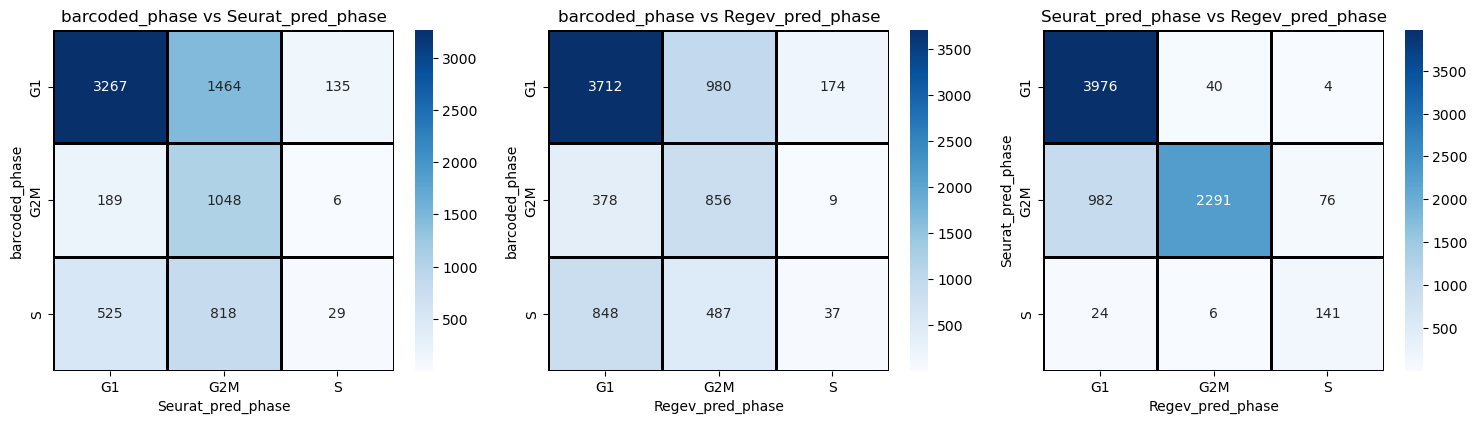

In [7]:
columns = [
    'barcoded_phase',
    'Seurat_pred_phase',
    'Regev_pred_phase',
]

# Compute all unique labels across all columns
all_labels = sorted(set().union(*[adata.obs[col].dropna().unique() for col in columns]))

# Generate all pairs
pairs = list(combinations(columns, 2))
n = len(pairs)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5 * ncols, 4 * nrows))

for ax, (col1, col2) in zip(axes.flat, pairs):
    mask = adata.obs[[col1, col2]].notnull().all(axis=1)
    y_true = adata.obs.loc[mask, col1]
    y_pred = adata.obs.loc[mask, col2]

    cm = confusion_matrix(y_true, y_pred, labels=all_labels)

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=all_labels,
        yticklabels=all_labels,
        ax=ax,
        lw=1,
        linecolor='k',
        square=True,
    )
    ax.set_xlabel(col2)
    ax.set_ylabel(col1)
    ax.set_title(f"{col1} vs {col2}")

# Hide unused axes
for i in range(n, nrows * ncols):
    fig.delaxes(axes.flat[i])

plt.tight_layout()
plt.show()


# Develop an Embedding

extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
[2025-05-08 13:00:49.775] [CUML] [debug] n_neighbors=100
[2025-05-08 13:00:49.775] [CUML] [debug] Calling knn graph run
[2025-05-08 13:00:49.775] [CUML] [debug] Done. Calling fuzzy simplicial set
[2025-05-08 13:00:49.803] [CUML] [debug] Done. Calling remove zeros


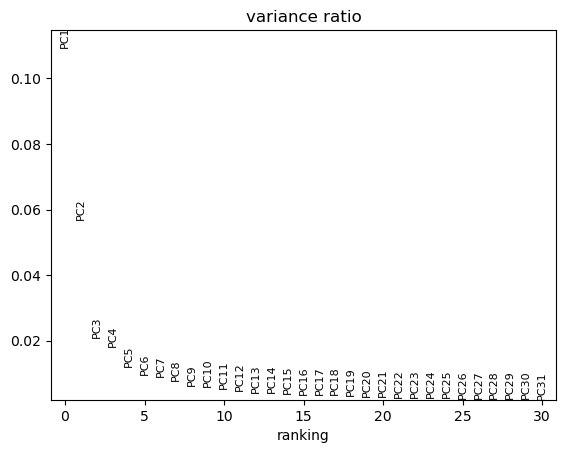

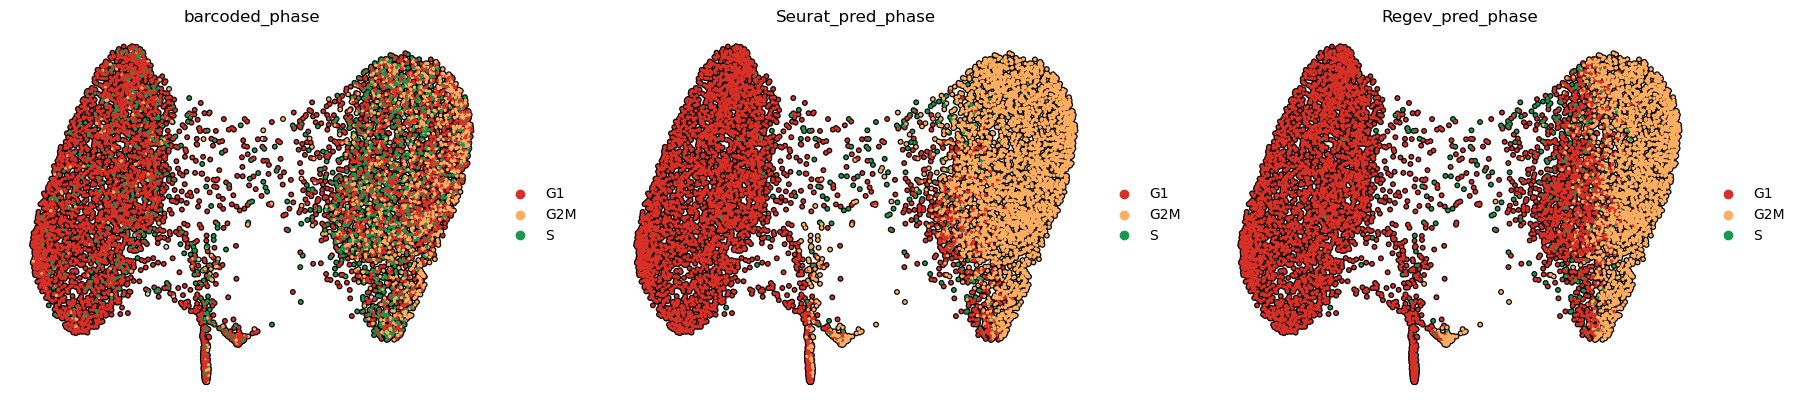

CPU times: user 2.7 s, sys: 1.13 s, total: 3.83 s
Wall time: 4.44 s


In [8]:
%%time
# feature selection
sc.pp.highly_variable_genes(adata)

# rapids
rsc.pp.pca(adata)
rsc.pp.neighbors(adata, n_neighbors=100, n_pcs=5)
rsc.tl.draw_graph(adata)

sc.pl.pca_variance_ratio(adata)

palette = {
    "G1": "#D73027",        # strong red (Cdt1+)
    "S": "#1A9850",         # green (Geminin+)
    "G2M": "#FDAE61",       # orange-yellow (Cdt1+/Geminin+)
}

sc.pl.draw_graph(
    adata, 
    color=columns,
    size=25,
    ncols=3,
    alpha=1,
    use_raw=False,
    add_outline=True,
    na_in_legend=False,
    outline_color=('k', 'k'),
    frameon=False,
    palette=palette,
)

In [9]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)